# Тема: Статистические данные о занятости и безработице среди населения по возрастным группам

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, ttest_ind, kruskal


# Загрузка данных

In [3]:
data_path = "data.csv"
uploaded_data = pd.read_csv(data_path)

# Настройка стиля визуализации

In [4]:
sns.set(style="whitegrid")


# 1. Описательные статистики

In [5]:
desc_stats = uploaded_data.describe()
print("Описательные статистики:\n", desc_stats)

Описательные статистики:
        num_economactivepopulation_all  employed_num_all  unemployed_num_all  \
count                      829.000000        829.000000          829.000000   
mean                      2449.539083       2295.550060          209.420145   
std                       8181.816668       7674.074172         1612.042537   
min                         22.100000         20.400000            0.900000   
25%                        430.300000        389.300000           27.600000   
50%                        677.900000        635.200000           48.300000   
75%                       1406.300000       1309.200000           97.800000   
max                      76587.500000      72323.600000        43981.000000   

       eactivity_lvl  employment_lvl  unemployment_lvl  dis_unagegroup_to20  \
count     829.000000      829.000000        829.000000           827.000000   
mean       66.671773       61.581785         60.830881             5.754414   
std         4.553769     

# 2. Проверка пропусков

In [6]:
missing_values = uploaded_data.isnull().sum()
print("\nПропуски в данных:\n", missing_values)


Пропуски в данных:
 territory                          0
num_economactivepopulation_all     2
employed_num_all                   2
unemployed_num_all                 2
eactivity_lvl                      2
employment_lvl                     2
unemployment_lvl                   2
dis_unagegroup_to20                4
dis_unagegroup_20-29               2
dis_unagegroup_30-39               2
dis_unagegroup_40-49               2
dis_unagegroup_50-59               2
dis_unagegroup_60older            16
dis_emagegroup_to20                4
dis_emagegroup_20-29               2
dis_emagegroup_30-39               2
dis_emagegroup_40-49               2
dis_emagegroup_50-59               2
dis_emagegroup_60older             2
num_unagegroup_to20                3
num_unagegroup_20-29               2
num_unagegroup_30-39               2
num_unagegroup_40-49               2
num_unagegroup_50-59               2
num_unagegroup_60older            14
num_emagegroup_to20                3
num_emagegroup_20

# Строю график чтоб посмотреть в будущем идет ли отклонение или нет

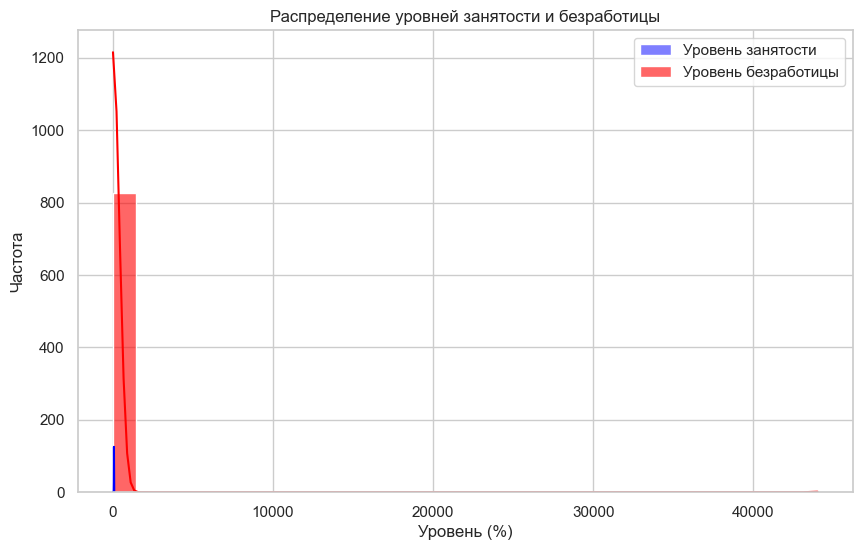

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(uploaded_data['employment_lvl'], bins=30, kde=True, color='blue', label='Уровень занятости')
sns.histplot(uploaded_data['unemployment_lvl'], bins=30, kde=True, color='red', label='Уровень безработицы', alpha=0.6)
plt.title("Распределение уровней занятости и безработицы")
plt.xlabel("Уровень (%)")
plt.ylabel("Частота")
plt.legend()
plt.show()

# Заполнение пропусков
# Числовые переменные заполняем медианой

In [18]:
numerical_cols = uploaded_data.select_dtypes(include=['float64', 'int64']).columns
uploaded_data[numerical_cols] = uploaded_data[numerical_cols].fillna(uploaded_data[numerical_cols].median())

# Категориальные переменные заполняем модой


In [19]:
categorical_cols = uploaded_data.select_dtypes(include=['object']).columns
uploaded_data[categorical_cols] = uploaded_data[categorical_cols].fillna(uploaded_data[categorical_cols].mode().iloc[0])

# Проверяем снова пропуски после заполнения


In [20]:
missing_values_after = uploaded_data.isnull().sum()
print("\nПропуски после заполнения:\n", missing_values_after)


Пропуски после заполнения:
 territory                         0
num_economactivepopulation_all    0
employed_num_all                  0
unemployed_num_all                0
eactivity_lvl                     0
employment_lvl                    0
unemployment_lvl                  0
dis_unagegroup_to20               0
dis_unagegroup_20-29              0
dis_unagegroup_30-39              0
dis_unagegroup_40-49              0
dis_unagegroup_50-59              0
dis_unagegroup_60older            0
dis_emagegroup_to20               0
dis_emagegroup_20-29              0
dis_emagegroup_30-39              0
dis_emagegroup_40-49              0
dis_emagegroup_50-59              0
dis_emagegroup_60older            0
num_unagegroup_to20               0
num_unagegroup_20-29              0
num_unagegroup_30-39              0
num_unagegroup_40-49              0
num_unagegroup_50-59              0
num_unagegroup_60older            0
num_emagegroup_to20               0
num_emagegroup_20-29              0

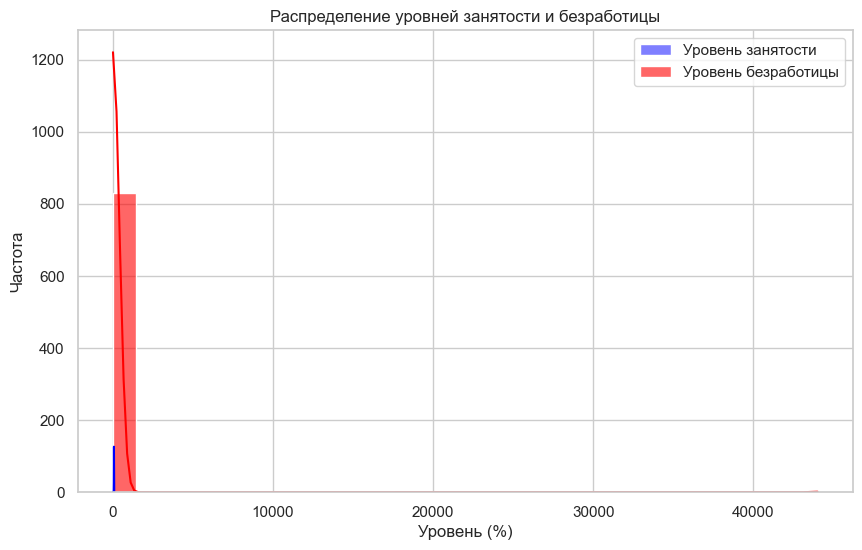

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(uploaded_data['employment_lvl'], bins=30, kde=True, color='blue', label='Уровень занятости')
sns.histplot(uploaded_data['unemployment_lvl'], bins=30, kde=True, color='red', label='Уровень безработицы', alpha=0.6)
plt.title("Распределение уровней занятости и безработицы")
plt.xlabel("Уровень (%)")
plt.ylabel("Частота")
plt.legend()
plt.show()

# 3. Распределение уровней занятости и безработицы


In [22]:
russia_data = uploaded_data[uploaded_data['territory'] == 'Российская Федерация']


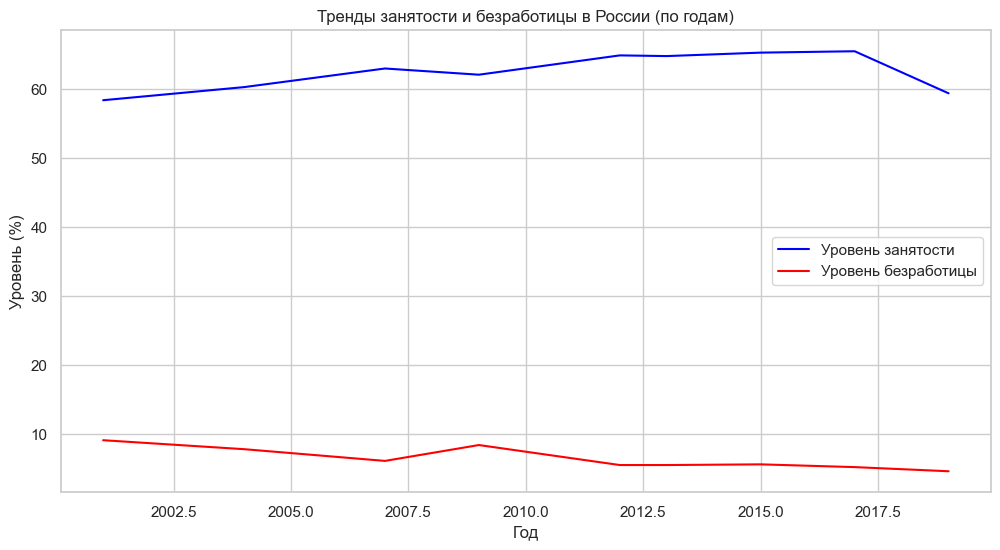

In [23]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=russia_data, x='year', y='employment_lvl', label='Уровень занятости', color='blue')
sns.lineplot(data=russia_data, x='year', y='unemployment_lvl', label='Уровень безработицы', color='red')
plt.title("Тренды занятости и безработицы в России (по годам)")
plt.xlabel("Год")
plt.ylabel("Уровень (%)")
plt.legend()
plt.show()

# 4. Сравнение регионов по уровню безработицы


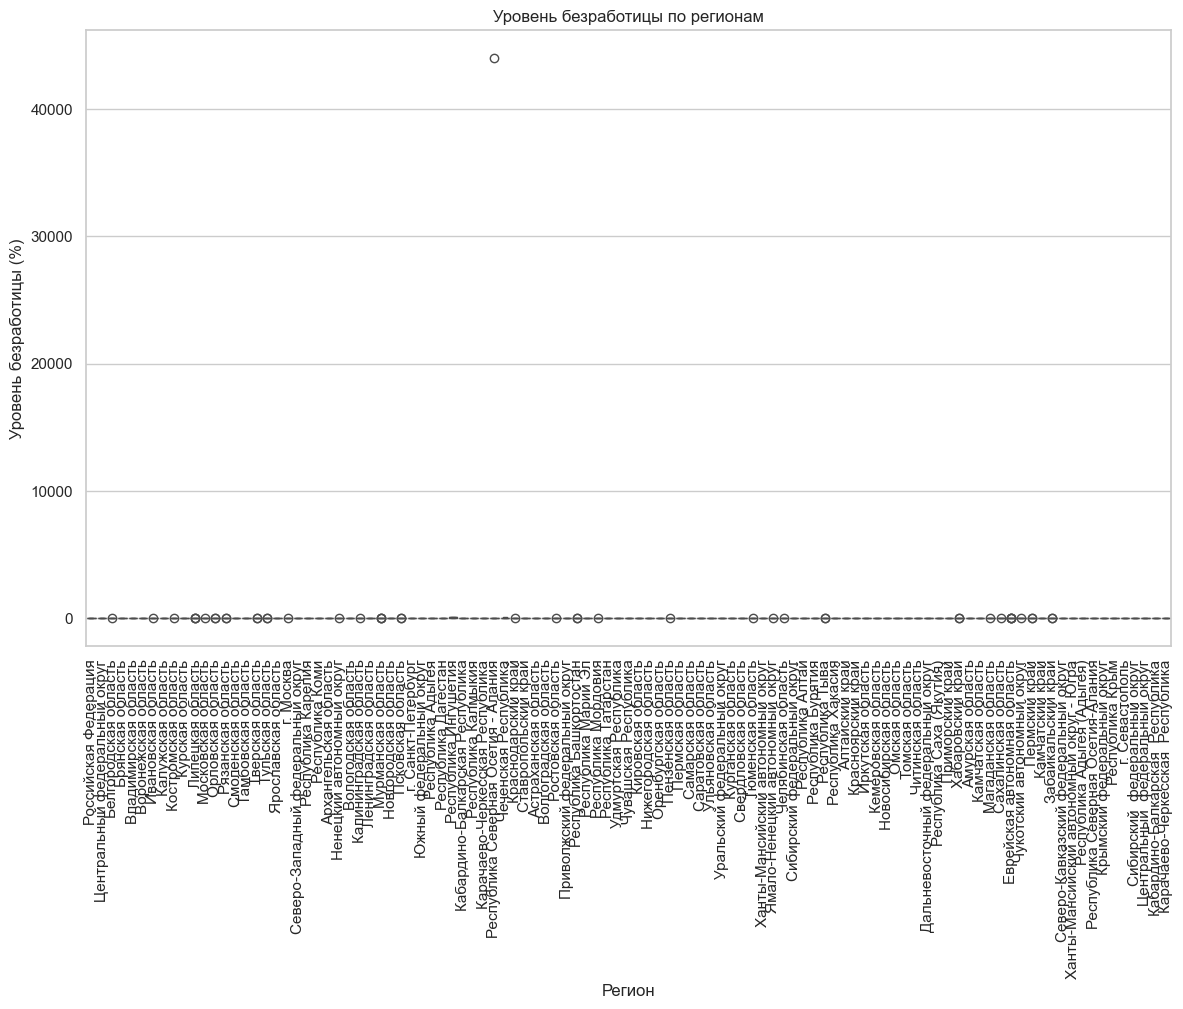

In [24]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=uploaded_data, x='territory', y='unemployment_lvl')
plt.xticks(rotation=90)
plt.title("Уровень безработицы по регионам")
plt.xlabel("Регион")
plt.ylabel("Уровень безработицы (%)")
plt.show()

# 5. Распределение безработных по возрастным группам (пример для группы 20-29 лет)


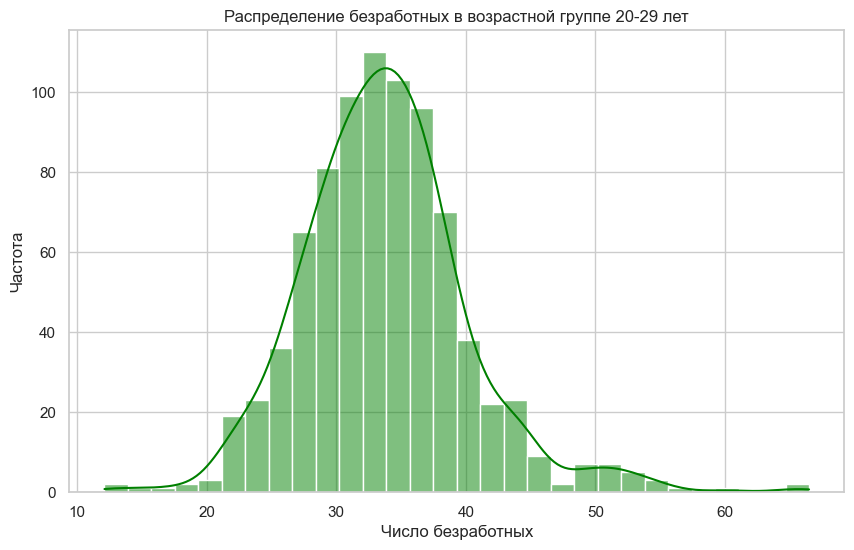

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(uploaded_data['dis_unagegroup_20-29'], bins=30, kde=True, color='green')
plt.title("Распределение безработных в возрастной группе 20-29 лет")
plt.xlabel("Число безработных")
plt.ylabel("Частота")
plt.show()

# **Проверка гипотез**

# Гипотеза 1: Уровень занятости выше в регионах с высоким уровнем экономической активности


In [26]:
eactivity_high = uploaded_data[uploaded_data['eactivity_lvl'] > uploaded_data['eactivity_lvl'].median()]
eactivity_low = uploaded_data[uploaded_data['eactivity_lvl'] <= uploaded_data['eactivity_lvl'].median()]
t_stat1, p_value1 = ttest_ind(eactivity_high['employment_lvl'], eactivity_low['employment_lvl'], equal_var=False)

# Гипотеза 2: Уровень безработицы выше среди молодежи (до 30 лет)


In [27]:
youth_unemployment = uploaded_data['dis_unagegroup_20-29']
older_unemployment = uploaded_data['dis_unagegroup_30-39']
t_stat2, p_value2 = ttest_ind(youth_unemployment.dropna(), older_unemployment.dropna(), equal_var=False)

# Гипотеза 3: Уровень безработицы различается между регионами


In [28]:
kruskal_stat, kruskal_p = kruskal(
    *[group['unemployment_lvl'].dropna() for _, group in uploaded_data.groupby('territory')]
)

# Гипотеза 4: Есть временные тренды в уровнях безработицы


In [29]:
corr_year_unemployment, p_year_unemployment = pearsonr(russia_data['year'], russia_data['unemployment_lvl'])

# Гипотеза 5: Экономическая активность коррелирует с числом занятых


In [30]:
corr_eactivity_employed, p_eactivity_employed = spearmanr(uploaded_data['eactivity_lvl'], uploaded_data['employed_num_all'])

# Сбор и вывод результатов


In [32]:
results = {
    "Гипотеза 1 (t-тест: занятость и активность)": (t_stat1, p_value1),
    "Гипотеза 2 (t-тест: безработица по возрастам)": (t_stat2, p_value2),
    "Гипотеза 3 (Крускал-Уоллис: безработица по регионам)": (kruskal_stat, kruskal_p),
    "Гипотеза 4 (Корреляция: год и безработица)": (corr_year_unemployment, p_year_unemployment),
    "Гипотеза 5 (Спирмен: активность и занятость)": (corr_eactivity_employed, p_eactivity_employed),
}

results_df = pd.DataFrame.from_dict(results, orient="index", columns=["Статистика", "p-значение"])
print("\nРезультаты статистических тестов:")
print(results_df)


Результаты статистических тестов:
                                                    Статистика     p-значение
Гипотеза 1 (t-тест: занятость и активность)          22.921464   2.213016e-90
Гипотеза 2 (t-тест: безработица по возрастам)        40.582004  5.141584e-243
Гипотеза 3 (Крускал-Уоллис: безработица по реги...  488.378145   4.311058e-51
Гипотеза 4 (Корреляция: год и безработица)           -0.875150   1.999726e-03
Гипотеза 5 (Спирмен: активность и занятость)          0.054082   1.192747e-01


# Вывод

## **Гипотеза 1: Регионы с более высокой экономической активностью имеют более высокий уровень занятости.**
- **Что получилось:**
  Уровень занятости в регионах с высокой экономической активностью действительно выше. Это подтверждено, так как \( p \)-значение очень маленькое (\( 2.21 \times 10^{-90} \)).
- **Почему так:**
  Экономически активные регионы, как правило, имеют больше рабочих мест и возможностей для трудоустройства.

---

## **Гипотеза 2: Молодежь (до 30 лет) чаще безработная, чем люди старше 30 лет.**
- **Что получилось:**
  Уровень безработицы среди молодежи гораздо выше, чем среди старших возрастных групп. \( p \)-значение (\( 5.14 \times 10^{-243} \)) показывает, что это значимое различие.
- **Почему так:**
  Молодежь часто имеет меньше опыта, что может усложнять трудоустройство. Кроме того, многие молодые люди ещё учатся и не работают.

---

## **Гипотеза 3: Уровень безработицы отличается в разных регионах.**
- **Что получилось:**
  Да, уровень безработицы сильно отличается между регионами. Это подтверждено статистически (\( p \)-значение \( 4.31 \times 10^{-51} \)).
- **Почему так:**
  В разных регионах могут быть разные экономические условия, доступ к рабочим местам и уровни зарплат, что влияет на безработицу.

---

## **Гипотеза 4: Уровень безработицы снижается с годами.**
- **Что получилось:**
  Есть заметное снижение безработицы с годами. \( p \)-значение (\( 0.002 \)) говорит, что это значимо.
- **Почему так:**
  Возможно, это связано с улучшением экономики или более активной государственной политикой в области занятости.

---

## **Гипотеза 5: Уровень экономической активности связан с числом занятых.**
- **Что получилось:**
  Связь между экономической активностью и числом занятых оказалась слабой и статистически незначимой (\( p = 0.119 \)).
- **Почему так:**
  Возможно, в данных нет сильной зависимости, или на численность занятых влияют другие факторы, такие как доступность рабочих мест или миграция.

---

## **Почему такие выводы:**
- Если \( p \)-значение меньше 0.05, это значит, что различия или зависимости в данных **значимы** (не случайны).
- Для каждой гипотезы использовались подходящие статистические тесты:
  - **t-тест:** для проверки различий между двумя группами (например, молодежь и старшие).
  - **Крускал-Уоллис:** для проверки различий между несколькими группами (например, регионами).
  - **Корреляция:** для проверки зависимости между переменными (например, год и безработица).

---

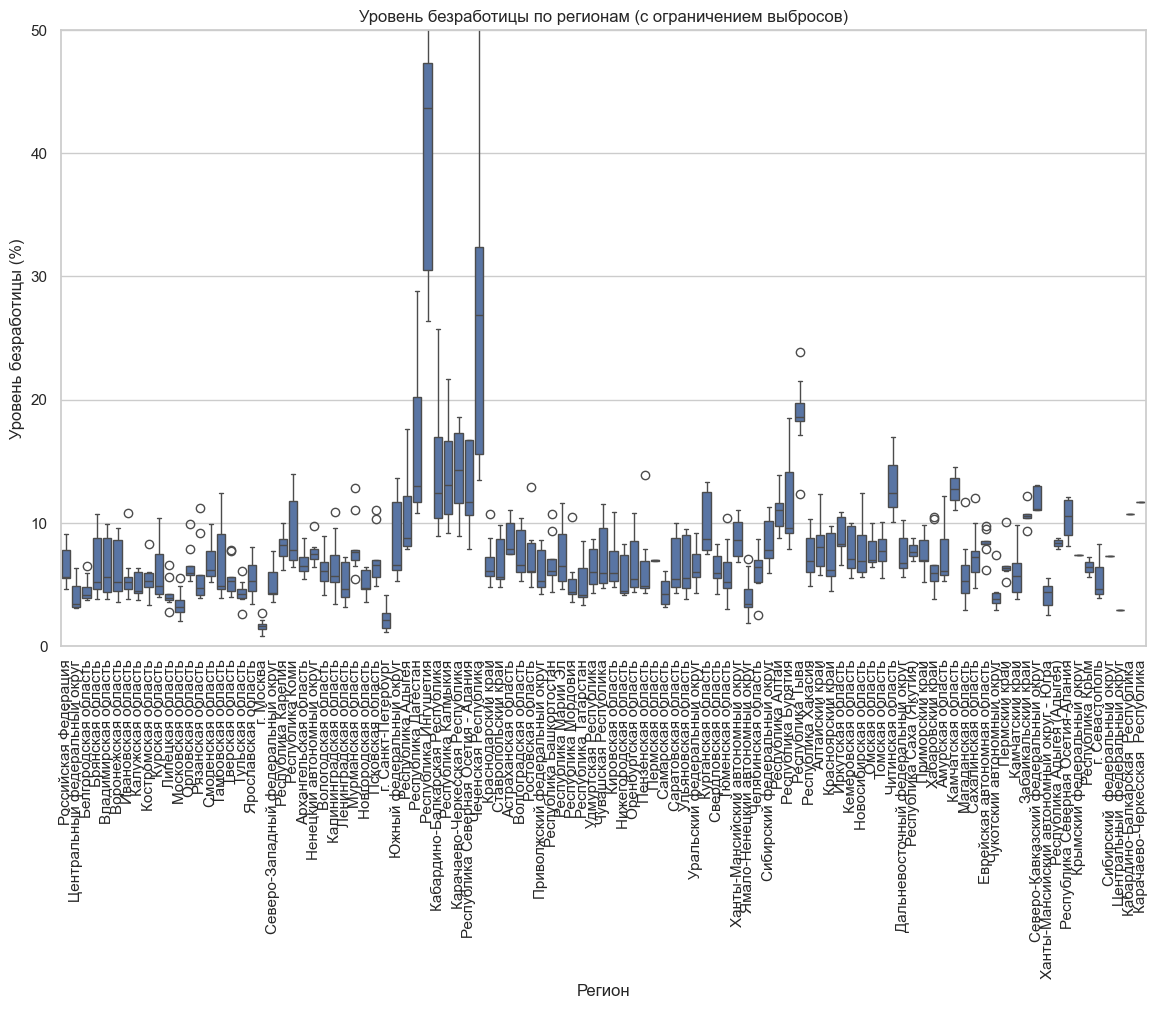

In [9]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=uploaded_data, x='territory', y='unemployment_lvl')
plt.ylim(0, 50)
plt.xticks(rotation=90)
plt.title("Уровень безработицы по регионам (с ограничением выбросов)")
plt.xlabel("Регион")
plt.ylabel("Уровень безработицы (%)")
plt.show()

# Выше график тоже не особо понятен так как сливаются регионы тут ниже описал топ 20 регионов по безработице

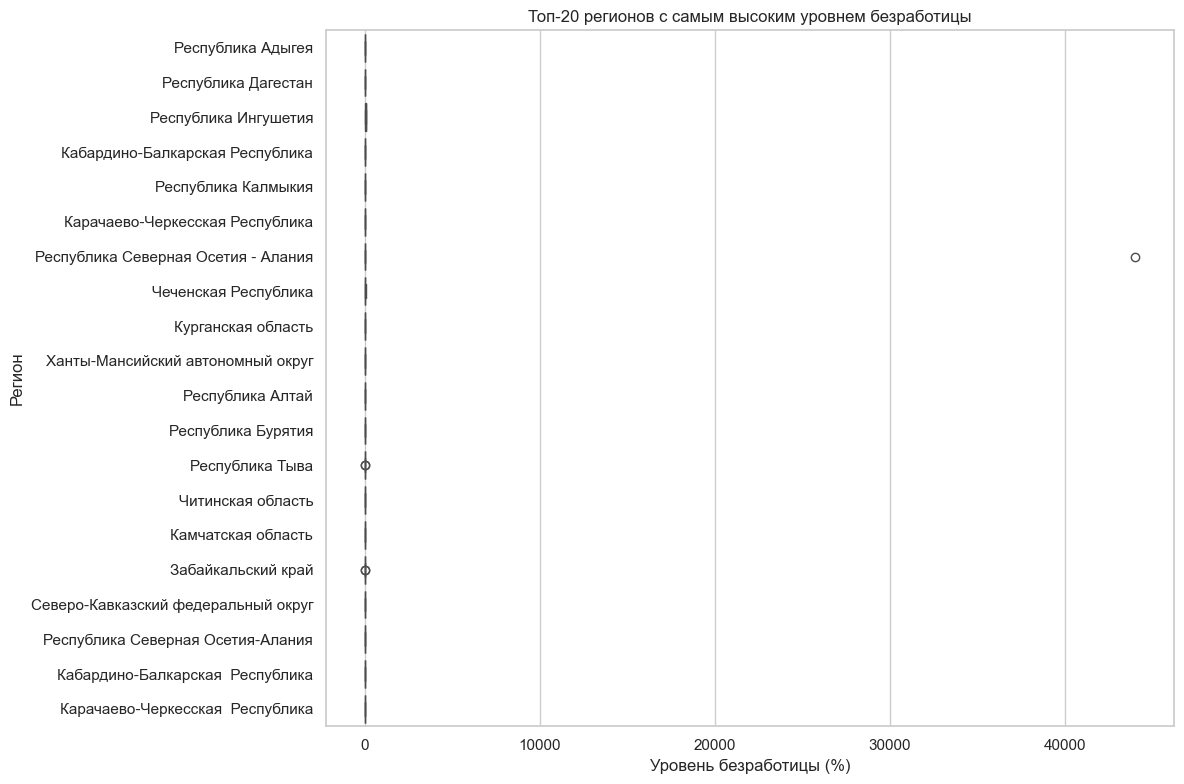

In [12]:
# Сортировка регионов по медианному уровню безработицы
region_medians = uploaded_data.groupby('territory')['unemployment_lvl'].median().sort_values()

# Отбор топ-20 регионов
top_regions = region_medians.tail(20).index
filtered_data = uploaded_data[uploaded_data['territory'].isin(top_regions)]

# Построение горизонтального боксплота для топ-20 регионов
plt.figure(figsize=(12, 8))
sns.boxplot(data=filtered_data, y='territory', x='unemployment_lvl', orient="h")
plt.title("Топ-20 регионов с самым высоким уровнем безработицы")
plt.xlabel("Уровень безработицы (%)")
plt.ylabel("Регион")
plt.tight_layout()
plt.show()

# Тут как просили поправил график по распределению уровней занятости

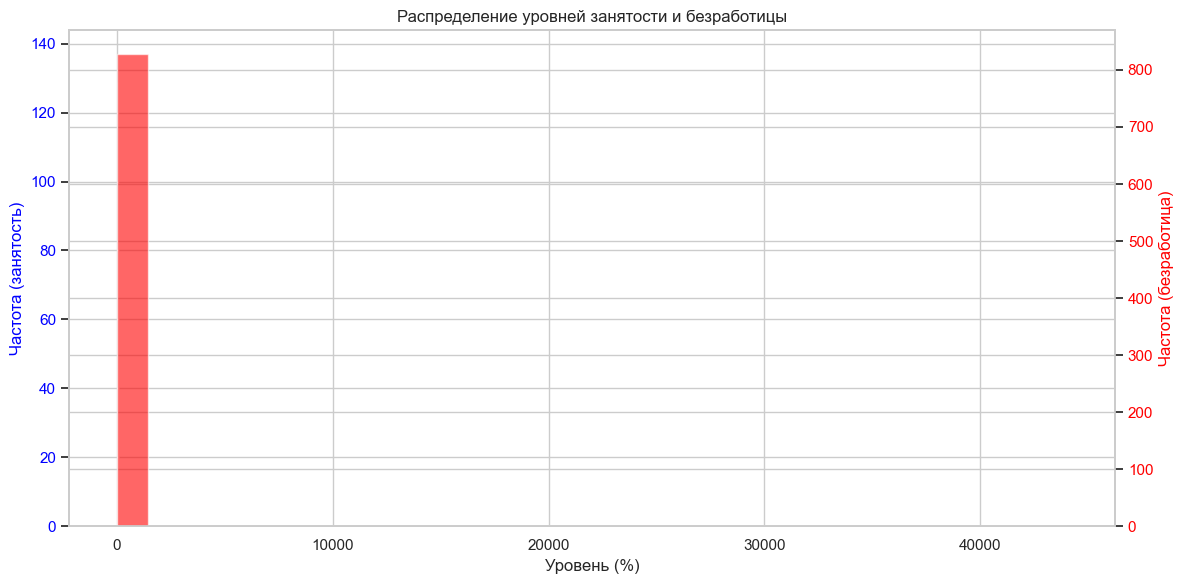

In [11]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.hist(uploaded_data['employment_lvl'], bins=30, color='blue', alpha=0.6, label='Уровень занятости')
ax1.set_xlabel("Уровень (%)")
ax1.set_ylabel("Частота (занятость)", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.hist(uploaded_data['unemployment_lvl'], bins=30, color='red', alpha=0.6, label='Уровень безработицы')
ax2.set_ylabel("Частота (безработица)", color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Распределение уровней занятости и безработицы")
fig.tight_layout()
plt.show()
